Mounted at /content/drive
 Barrios urbanos con temperatura: 271
 Puntos de temperatura creados: 271
 Cuadrícula creada: 10000 puntos
 Interpolación por proximidad completada


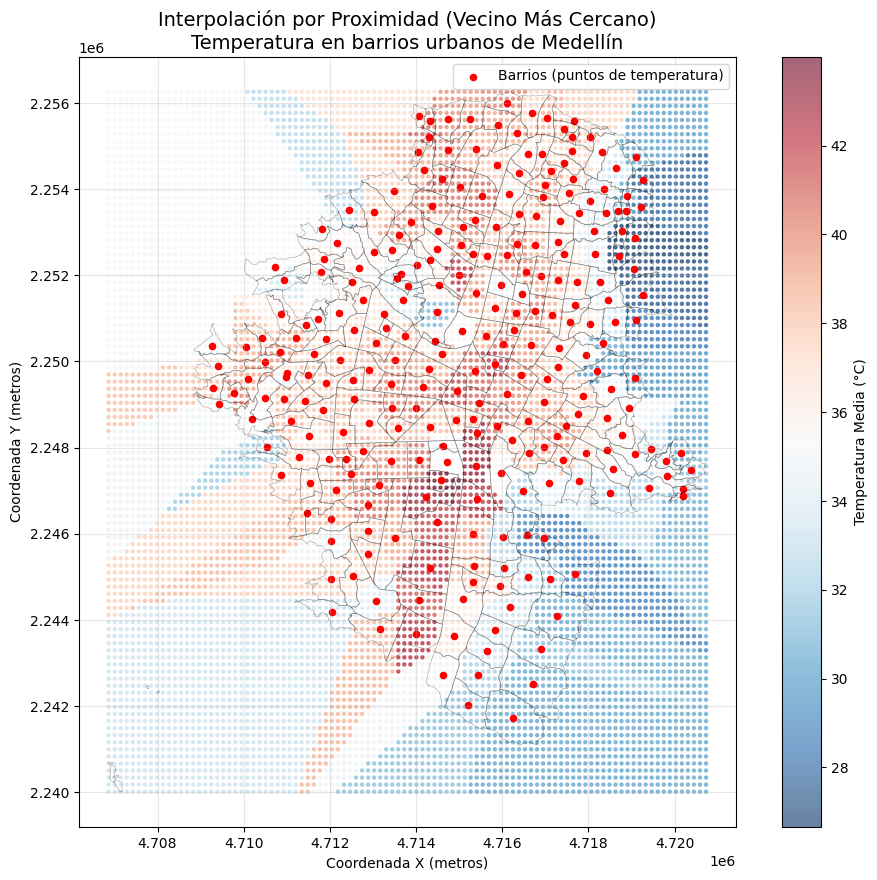

Mapa guardado en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies/Interpolacion_Proximidad_Temperatura_Urbano.png
Temperatura mínima interpolada: 26.66 °C
Temperatura máxima interpolada: 44.00 °C
Temperatura media interpolada: 34.87 °C

Temperatura media original (barrios): 36.58 °C


In [ ]:
# ============================================
# INSTALAR LIBRERÍAS NECESARIAS
# ============================================
# Ejecuta esto solo una vez en Colab
!pip install geopandas rasterio matplotlib descartes -q

# ============================================
# 1. IMPORTAR LIBRERÍAS
# ============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from shapely.geometry import Point
import os
from google.colab import drive

# Montar Google Drive para acceder a tus archivos
drive.mount('/content/drive')

# ============================================
# 2. CARGAR TUS DATOS (SOLO ÁREA URBANA)
# ============================================

ruta_zonas = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
ruta_temp = "/content/drive/My Drive//Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"

# Cargar zonas y filtrar solo urbano
zonas = gpd.read_file(ruta_zonas)
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()

# Cargar temperatura y calcular promedio por barrio
df_temp = pd.read_csv(ruta_temp)
temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()

# Unir temperatura a los barrios
zonas_urbano = zonas_urbano.merge(temp_promedio, left_index=True, right_on='ID', how='left')

# Eliminar barrios sin temperatura
zonas_urbano = zonas_urbano.dropna(subset=['Temp_media'])

print(f" Barrios urbanos con temperatura: {len(zonas_urbano)}")

# ============================================
# 3. EXTRAER COORDENADAS DE LOS BARRIOS (CENTROIDES)
# ============================================

# Calcular centroides de los barrios (puntos representativos)
zonas_urbano['centroid'] = zonas_urbano.geometry.centroid
zonas_urbano['x'] = zonas_urbano['centroid'].x
zonas_urbano['y'] = zonas_urbano['centroid'].y

# Crear un GeoDataFrame de puntos con temperatura
puntos_temp = gpd.GeoDataFrame(
    zonas_urbano[['Temp_media', 'x', 'y']],
    geometry=zonas_urbano['centroid'],
    crs=zonas_urbano.crs
)

print(f" Puntos de temperatura creados: {len(puntos_temp)}")

# ============================================
# 4. CREAR UNA CUADRÍCULA (GRID) PARA INTERPOLAR
# ============================================

# Obtener los límites del área urbana
xmin, ymin, xmax, ymax = zonas_urbano.total_bounds

# Crear una cuadrícula de puntos (resolución: 100x100 puntos)
resolucion = 100
x_vals = np.linspace(xmin, xmax, resolucion)
y_vals = np.linspace(ymin, ymax, resolucion)
x_grid, y_grid = np.meshgrid(x_vals, y_vals)

# Aplanar la cuadrícula para crear puntos
grid_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(x_grid.flatten(), y_grid.flatten()),
    crs=zonas_urbano.crs
)

print(f" Cuadrícula creada: {len(grid_points)} puntos")

# ============================================
# 5. INTERPOLACIÓN POR PROXIMIDAD (VECINO MÁS CERCANO)
# ============================================

# Preparar datos para el modelo
X_train = puntos_temp[['x', 'y']].values  # Coordenadas de los barrios
y_train = puntos_temp['Temp_media'].values  # Temperatura

# Crear el modelo de vecino más cercano (k=1)
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_train, y_train)

# Predecir temperatura en los puntos de la cuadrícula
X_pred = np.column_stack((grid_points.geometry.x, grid_points.geometry.y))
grid_points['Temp_interp'] = knn.predict(X_pred)

print(" Interpolación por proximidad completada")

# ============================================
# 6. VISUALIZACIÓN DE LOS RESULTADOS
# ============================================

fig, ax = plt.subplots(1, figsize=(12, 10))

# Mapa de la interpolación (fondo)
sc = ax.scatter(
    grid_points.geometry.x,
    grid_points.geometry.y,
    c=grid_points['Temp_interp'],
    cmap='RdBu_r',
    s=5,
    alpha=0.6,
    vmin=zonas_urbano['Temp_media'].min(),
    vmax=zonas_urbano['Temp_media'].max()
)

# Dibujar los límites de los barrios urbanos
zonas_urbano.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.3)

# Dibujar los puntos de temperatura originales
puntos_temp.plot(ax=ax, color='red', markersize=20, label='Barrios (puntos de temperatura)')

# Configurar el gráfico
plt.colorbar(sc, ax=ax, label='Temperatura Media (°C)')
ax.set_title('Interpolación por Proximidad (Vecino Más Cercano)\nTemperatura en barrios urbanos de Medellín', fontsize=14)
ax.set_xlabel('Coordenada X (metros)')
ax.set_ylabel('Coordenada Y (metros)')
ax.legend()
ax.grid(True, alpha=0.3)

# Guardar el mapa
ruta_resultados = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "Interpolacion_Proximidad_Temperatura_Urbano.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Mapa guardado en: {os.path.join(ruta_resultados, 'Interpolacion_Proximidad_Temperatura_Urbano.png')}")

# ============================================
# 7. ESTADÍSTICAS BÁSICAS DE LA INTERPOLACIÓN
# ============================================

print(f"Temperatura mínima interpolada: {grid_points['Temp_interp'].min():.2f} °C")
print(f"Temperatura máxima interpolada: {grid_points['Temp_interp'].max():.2f} °C")
print(f"Temperatura media interpolada: {grid_points['Temp_interp'].mean():.2f} °C")

# Comparar con los datos originales
print(f"\nTemperatura media original (barrios): {zonas_urbano['Temp_media'].mean():.2f} °C")

Barrios urbanos con temperatura: 271
Cuadrícula creada: 10000 puntos
Interpolación IDW completada


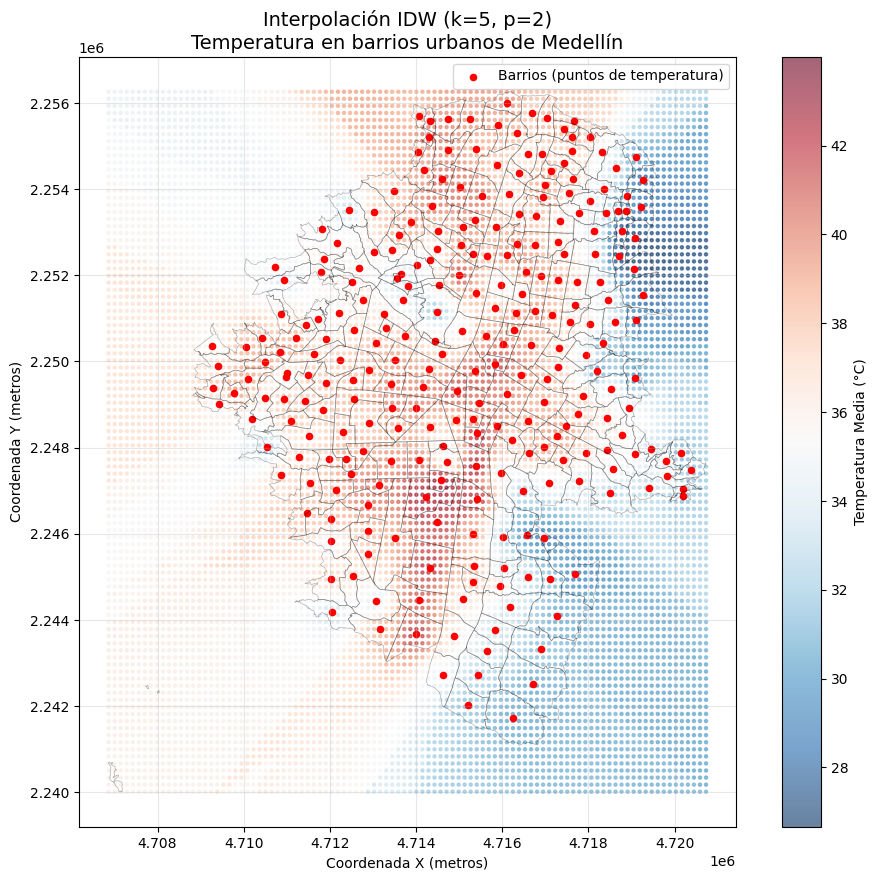

Mapa guardado en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies/IDW_Temperatura_Urbano.png


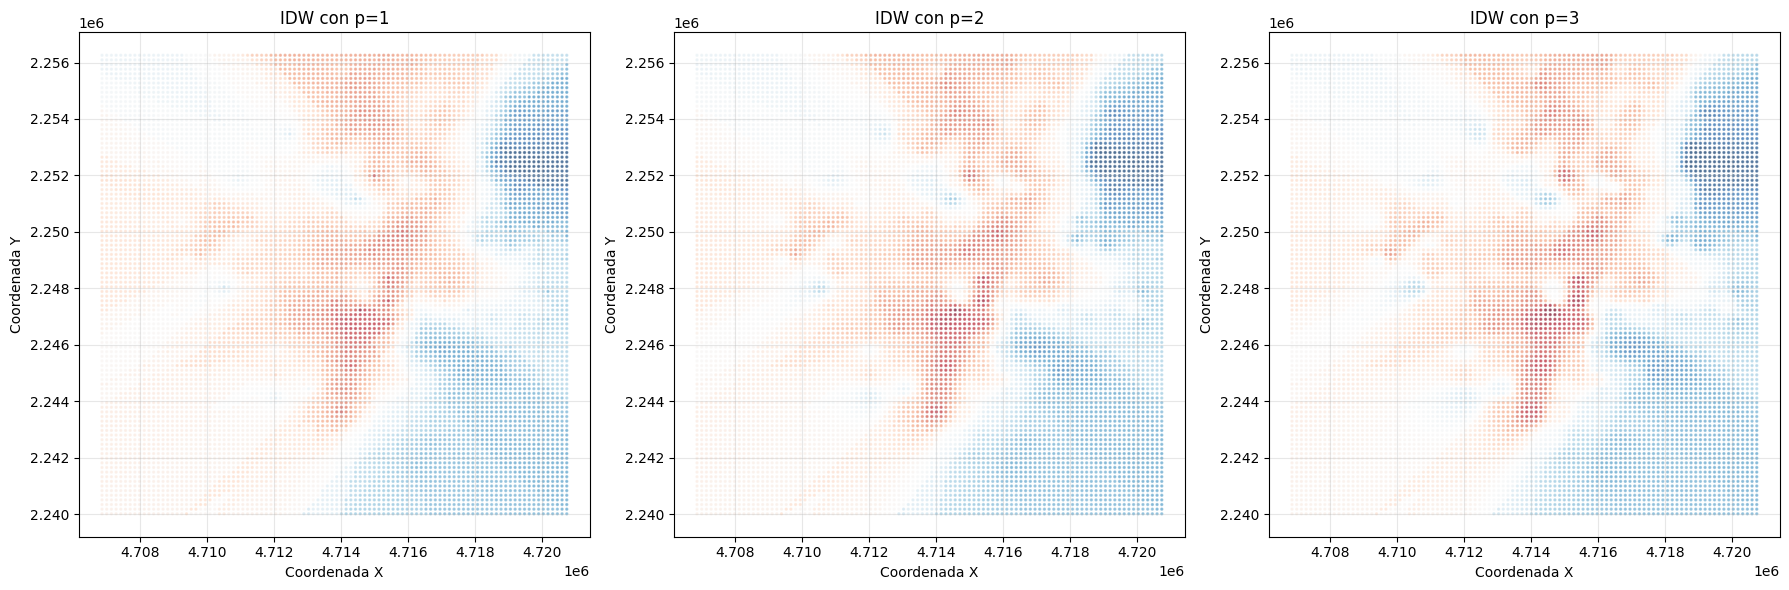

Comparación guardada en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies/IDW_Comparacion_Exponentes.png


In [ ]:
# ============================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from functools import partial
import os

# ============================================
# 2. CARGAR TUS DATOS (SOLO ÁREA URBANA)
# ============================================

ruta_zonas = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
ruta_temp = "/content/drive/My Drive//Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"

# Cargar zonas y filtrar solo urbano
zonas = gpd.read_file(ruta_zonas)
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()

# Cargar temperatura y calcular promedio por barrio
df_temp = pd.read_csv(ruta_temp)
temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()

# Unir temperatura a los barrios
zonas_urbano = zonas_urbano.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_urbano.dropna(subset=['Temp_media'])

print(f"Barrios urbanos con temperatura: {len(zonas_urbano)}")

# ============================================
# 3. EXTRAER COORDENADAS DE LOS BARRIOS (CENTROIDES)
# ============================================

# Calcular centroides
zonas_urbano['centroid'] = zonas_urbano.geometry.centroid
zonas_urbano['x'] = zonas_urbano['centroid'].x
zonas_urbano['y'] = zonas_urbano['centroid'].y

# Crear un GeoDataFrame de puntos con temperatura
puntos_temp = gpd.GeoDataFrame(
    zonas_urbano[['Temp_media', 'x', 'y']],
    geometry=zonas_urbano['centroid'],
    crs=zonas_urbano.crs
)

# ============================================
# 4. CREAR UNA CUADRÍCULA (GRID) PARA INTERPOLAR
# ============================================

# Obtener los límites del área urbana
xmin, ymin, xmax, ymax = zonas_urbano.total_bounds

# Crear una cuadrícula de puntos (resolución: 100x100 puntos)
resolucion = 100
x_vals = np.linspace(xmin, xmax, resolucion)
y_vals = np.linspace(ymin, ymax, resolucion)
x_grid, y_grid = np.meshgrid(x_vals, y_vals)

# Aplanar la cuadrícula para crear puntos
grid_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(x_grid.flatten(), y_grid.flatten()),
    crs=zonas_urbano.crs
)

print(f"Cuadrícula creada: {len(grid_points)} puntos")

# ============================================
# 5. DEFINIR LA FUNCIÓN DE PESOS IDW
# ============================================

def idw_weights(distances, p=2):
    """
    Calcula los pesos IDW para las distancias.
    p: exponente de la distancia (por defecto 2).
    """
    distances = distances.copy()
    # Evitar división por cero si hay distancias nulas
    distances[distances == 0] = 1e-12
    return 1 / distances**p

# ============================================
# 6. INTERPOLACIÓN IDW CON KNN (k=5, p=2)
# ============================================

# Preparar datos para el modelo
X_train = puntos_temp[['x', 'y']].values  # Coordenadas de los barrios
y_train = puntos_temp['Temp_media'].values  # Temperatura

# Crear el modelo KNN con pesos IDW (k=5 vecinos, exponente p=2)
model_idw = KNeighborsRegressor(
    n_neighbors=5,
    weights=partial(idw_weights, p=2)
)
model_idw.fit(X_train, y_train)

# Predecir temperatura en los puntos de la cuadrícula
X_pred = np.column_stack((grid_points.geometry.x, grid_points.geometry.y))
grid_points['Temp_idw'] = model_idw.predict(X_pred)

print("Interpolación IDW completada")

# ============================================
# 7. VISUALIZACIÓN DE LOS RESULTADOS
# ============================================

fig, ax = plt.subplots(1, figsize=(12, 10))

# Mapa de la interpolación IDW (fondo)
sc = ax.scatter(
    grid_points.geometry.x,
    grid_points.geometry.y,
    c=grid_points['Temp_idw'],
    cmap='RdBu_r',
    s=5,
    alpha=0.6,
    vmin=zonas_urbano['Temp_media'].min(),
    vmax=zonas_urbano['Temp_media'].max()
)

# Dibujar los límites de los barrios urbanos
zonas_urbano.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.3)

# Dibujar los puntos de temperatura originales
puntos_temp.plot(ax=ax, color='red', markersize=20, label='Barrios (puntos de temperatura)')

# Configurar el gráfico
plt.colorbar(sc, ax=ax, label='Temperatura Media (°C)')
ax.set_title('Interpolación IDW (k=5, p=2)\nTemperatura en barrios urbanos de Medellín', fontsize=14)
ax.set_xlabel('Coordenada X (metros)')
ax.set_ylabel('Coordenada Y (metros)')
ax.legend()
ax.grid(True, alpha=0.3)

# Guardar el mapa
ruta_resultados = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "IDW_Temperatura_Urbano.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Mapa guardado en: {os.path.join(ruta_resultados, 'IDW_Temperatura_Urbano.png')}")

# ============================================
# 8. EXPLORAR DIFERENTES EXPONENTES (p)
# ============================================
exponentes = [1, 2, 3]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, p in enumerate(exponentes):
    model = KNeighborsRegressor(n_neighbors=5, weights=partial(idw_weights, p=p))
    model.fit(X_train, y_train)
    grid_points[f'Temp_idw_p{p}'] = model.predict(X_pred)

    sc = axes[i].scatter(
        grid_points.geometry.x,
        grid_points.geometry.y,
        c=grid_points[f'Temp_idw_p{p}'],
        cmap='RdBu_r',
        s=2,
        alpha=0.5,
        vmin=zonas_urbano['Temp_media'].min(),
        vmax=zonas_urbano['Temp_media'].max()
    )
    axes[i].set_title(f'IDW con p={p}')
    axes[i].set_xlabel('Coordenada X')
    axes[i].set_ylabel('Coordenada Y')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_resultados, "IDW_Comparacion_Exponentes.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Comparación guardada en: {os.path.join(ruta_resultados, 'IDW_Comparacion_Exponentes.png')}")

Barrios urbanos con temperatura: 271
Coordenadas extraídas: 271 puntos
Triangulación de Delaunay calculada
Número de triángulos: 526
Número de puntos: 271


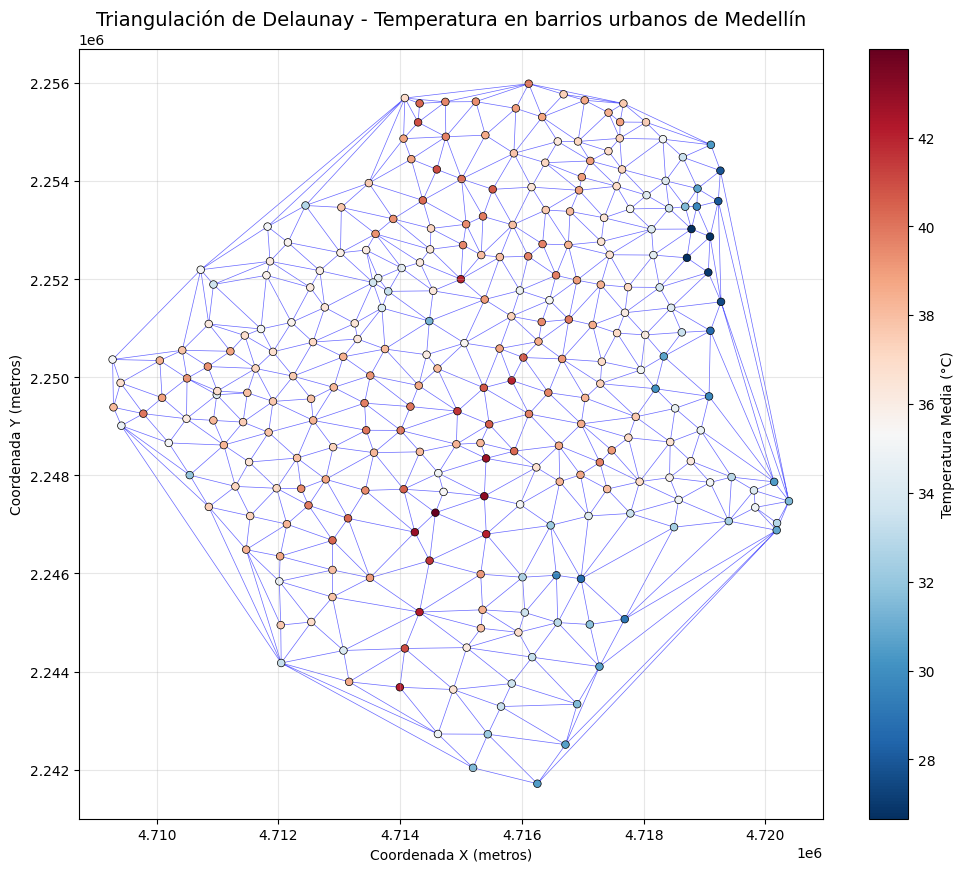

Mapa guardado en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies/Delaunay_Triangulacion_Temperatura_Urbano.png


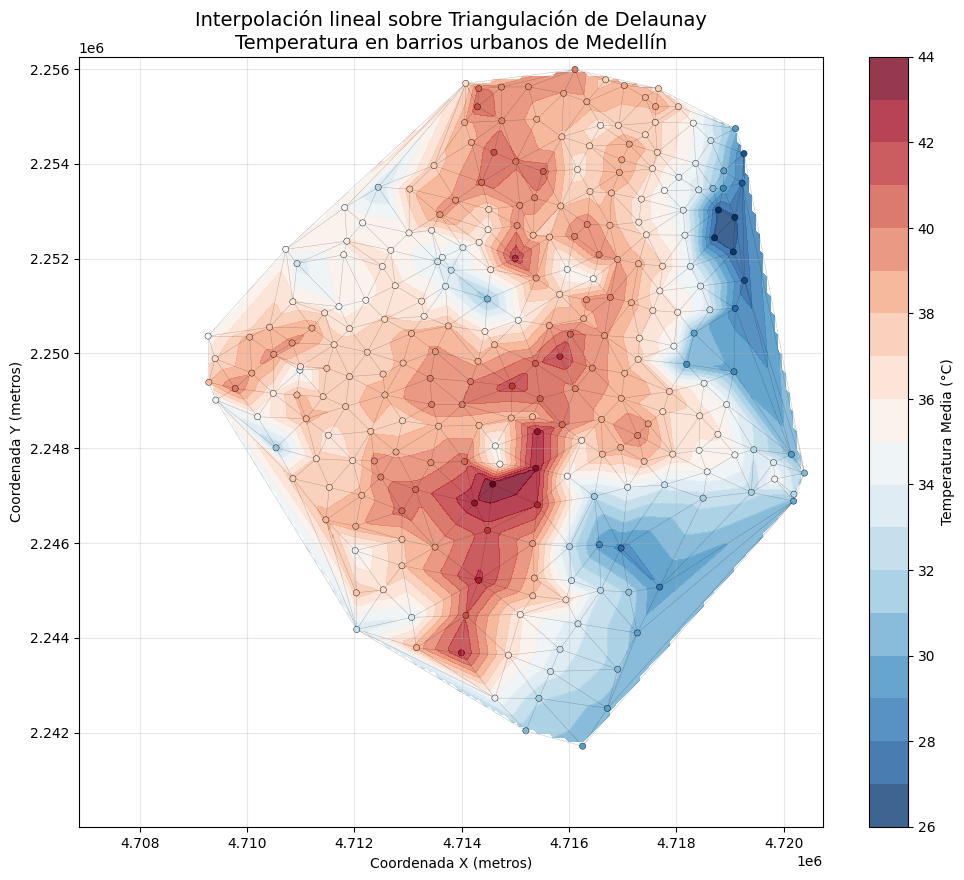

Mapa de interpolación guardado en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies/Delaunay_Interpolacion_Temperatura_Urbano.png
Número total de triángulos: 526
Área total del convex hull: 107.40 km²
Temperatura media de los triángulos: 36.62 °C
Temperatura mínima de los triángulos: 26.72 °C
Temperatura máxima de los triángulos: 43.03 °C


In [ ]:
# ============================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import os

# ============================================
# 2. CARGAR TUS DATOS (SOLO ÁREA URBANA)
# ============================================

ruta_zonas = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
ruta_temp = "/content/drive/My Drive//Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"

# Cargar zonas y filtrar solo urbano
zonas = gpd.read_file(ruta_zonas)
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()

# Cargar temperatura y calcular promedio por barrio
df_temp = pd.read_csv(ruta_temp)
temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()

# Unir temperatura a los barrios
zonas_urbano = zonas_urbano.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_urbano.dropna(subset=['Temp_media'])

print(f"Barrios urbanos con temperatura: {len(zonas_urbano)}")

# ============================================
# 3. EXTRAER COORDENADAS DE LOS BARRIOS (CENTROIDES)
# ============================================

# Calcular centroides
zonas_urbano['centroid'] = zonas_urbano.geometry.centroid
zonas_urbano['x'] = zonas_urbano['centroid'].x
zonas_urbano['y'] = zonas_urbano['centroid'].y

# Crear un array de coordenadas para Delaunay
coords = np.column_stack((zonas_urbano['x'], zonas_urbano['y']))

print(f"Coordenadas extraídas: {len(coords)} puntos")

# ============================================
# 4. CALCULAR LA TRIANGULACIÓN DE DELAUNAY
# ============================================

# Calcular la triangulación
tri = Delaunay(coords)

print(f"Triangulación de Delaunay calculada")
print(f"Número de triángulos: {len(tri.simplices)}")
print(f"Número de puntos: {len(tri.points)}")

# ============================================
# 5. VISUALIZACIÓN DE LA TRIANGULACIÓN
# ============================================

fig, ax = plt.subplots(1, figsize=(12, 10))

# Dibujar la triangulación
ax.triplot(coords[:, 0], coords[:, 1], tri.simplices, color='blue', linewidth=0.5, alpha=0.6)

# Dibujar los puntos (centroides de los barrios) con color según temperatura
sc = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=zonas_urbano['Temp_media'],
    cmap='RdBu_r',
    s=30,
    edgecolor='black',
    linewidth=0.5,
    vmin=zonas_urbano['Temp_media'].min(),
    vmax=zonas_urbano['Temp_media'].max()
)

# Configurar el gráfico
plt.colorbar(sc, ax=ax, label='Temperatura Media (°C)')
ax.set_title('Triangulación de Delaunay - Temperatura en barrios urbanos de Medellín', fontsize=14)
ax.set_xlabel('Coordenada X (metros)')
ax.set_ylabel('Coordenada Y (metros)')
ax.grid(True, alpha=0.3)

# Guardar el mapa
ruta_resultados = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "Delaunay_Triangulacion_Temperatura_Urbano.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Mapa guardado en: {os.path.join(ruta_resultados, 'Delaunay_Triangulacion_Temperatura_Urbano.png')}")

# ============================================
# 6. MAPA DE TEMPERATURA SOBRE LA TRIANGULACIÓN
# ============================================

# Interpolar linealmente la temperatura en cada triángulo
from matplotlib.tri import Triangulation, LinearTriInterpolator

# Crear la triangulación para matplotlib
triang = Triangulation(coords[:, 0], coords[:, 1], tri.simplices)

# Crear el interpolador lineal
interpolator = LinearTriInterpolator(triang, zonas_urbano['Temp_media'])

# Crear una cuadrícula fina para la interpolación
xmin, ymin, xmax, ymax = zonas_urbano.total_bounds
x_grid = np.linspace(xmin, xmax, 200)
y_grid = np.linspace(ymin, ymax, 200)
x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)

# Interpolar en la cuadrícula
z_interp = interpolator(x_mesh, y_mesh)

# Visualizar el mapa de temperatura interpolado
fig, ax = plt.subplots(1, figsize=(12, 10))

# Mapa de temperatura
im = ax.contourf(x_mesh, y_mesh, z_interp, levels=20, cmap='RdBu_r', alpha=0.8)

# Dibujar la triangulación en la parte superior
ax.triplot(coords[:, 0], coords[:, 1], tri.simplices, color='black', linewidth=0.3, alpha=0.3)

# Dibujar los puntos originales
ax.scatter(coords[:, 0], coords[:, 1], c=zonas_urbano['Temp_media'], cmap='RdBu_r', s=20, edgecolor='black', linewidth=0.3)

plt.colorbar(im, ax=ax, label='Temperatura Media (°C)')
ax.set_title('Interpolación lineal sobre Triangulación de Delaunay\nTemperatura en barrios urbanos de Medellín', fontsize=14)
ax.set_xlabel('Coordenada X (metros)')
ax.set_ylabel('Coordenada Y (metros)')
ax.grid(True, alpha=0.3)

plt.savefig(os.path.join(ruta_resultados, "Delaunay_Interpolacion_Temperatura_Urbano.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Mapa de interpolación guardado en: {os.path.join(ruta_resultados, 'Delaunay_Interpolacion_Temperatura_Urbano.png')}")

# ============================================
# 7. ESTADÍSTICAS DE LA TRIANGULACIÓN
# ============================================

# Número de triángulos
print(f"Número total de triángulos: {len(tri.simplices)}")

# Área total de la triangulación (opcional, requiere shapely)
from shapely.geometry import Polygon
try:
    # Crear un polígono a partir de los puntos extremos (convex hull)
    from scipy.spatial import ConvexHull
    hull = ConvexHull(coords)
    hull_polygon = Polygon(coords[hull.vertices])
    area_total = hull_polygon.area / 1_000_000  # Convertir a km²
    print(f"Área total del convex hull: {area_total:.2f} km²")
except:
    pass

# Temperatura media por triángulo (aproximación)
temp_triangles = []
for simplex in tri.simplices:
    temp_tri = zonas_urbano.iloc[simplex]['Temp_media'].mean()
    temp_triangles.append(temp_tri)

print(f"Temperatura media de los triángulos: {np.mean(temp_triangles):.2f} °C")
print(f"Temperatura mínima de los triángulos: {np.min(temp_triangles):.2f} °C")
print(f"Temperatura máxima de los triángulos: {np.max(temp_triangles):.2f} °C")

Barrios urbanos con temperatura: 271
Coordenadas extraídas: 271 puntos
Diagrama de Voronoi calculado
Número de vértices: 526
Número de regiones: 272
Polígonos de Voronoi creados: 271
Temperaturas asignadas a 271 polígonos


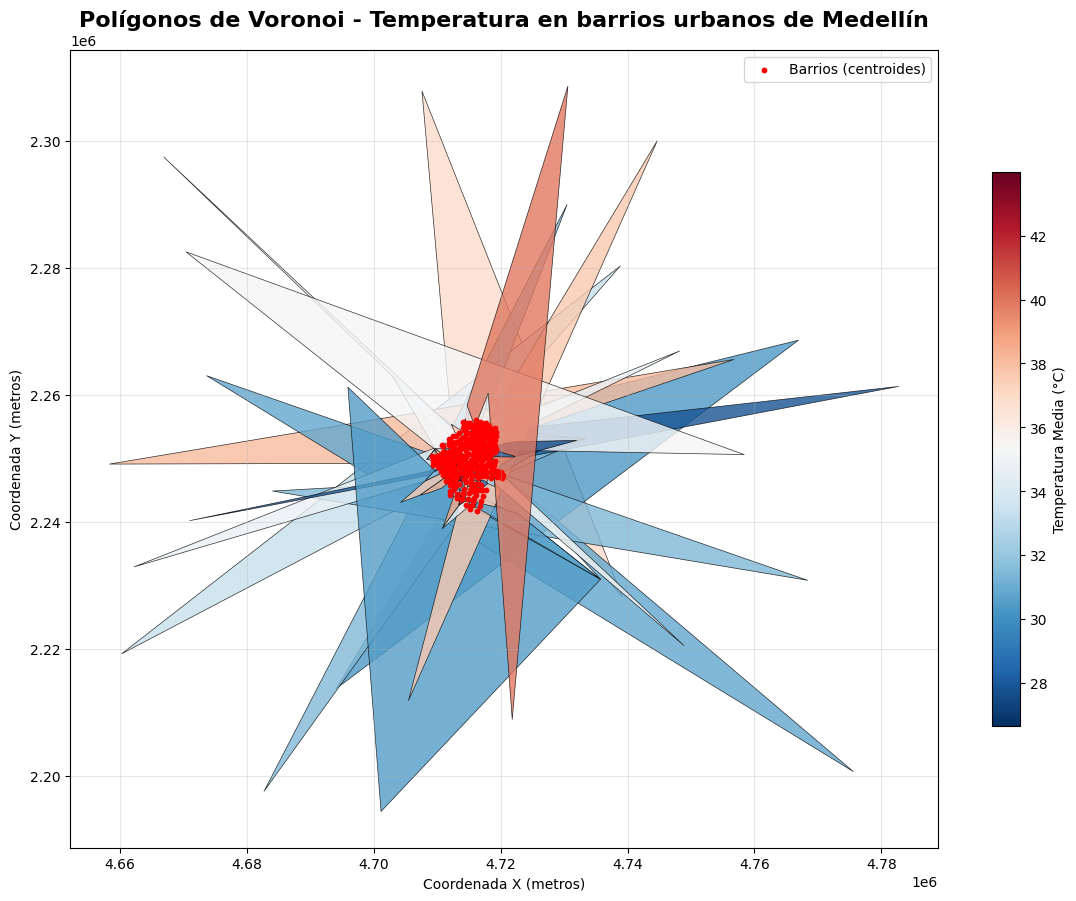

Mapa guardado en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies/Voronoi_Temperatura_Urbano.png
Polígonos de Voronoi guardados en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies/Voronoi_Temperatura_Urbano.gpkg
Área promedio de los polígonos: 25.94 km²
Área mínima: 0.11 km²
Área máxima: 1173.03 km²

Temperatura promedio en los polígonos: 36.58 °C
Temperatura mínima: 26.66 °C
Temperatura máxima: 44.00 °C


In [ ]:
# ============================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
from shapely.geometry import Polygon
import os

# ============================================
# 2. CARGAR TUS DATOS (SOLO ÁREA URBANA)
# ============================================
ruta_zonas = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
ruta_temp = "/content/drive/My Drive//Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"

# Cargar zonas y filtrar solo urbano
zonas = gpd.read_file(ruta_zonas)
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()

# Cargar temperatura y calcular promedio por barrio
df_temp = pd.read_csv(ruta_temp)
temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()

# Unir temperatura a los barrios
zonas_urbano = zonas_urbano.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_urbano.dropna(subset=['Temp_media'])

print(f"Barrios urbanos con temperatura: {len(zonas_urbano)}")

# ============================================
# 3. EXTRAER COORDENADAS DE LOS BARRIOS (CENTROIDES)
# ============================================

# Calcular centroides
zonas_urbano['centroid'] = zonas_urbano.geometry.centroid
zonas_urbano['x'] = zonas_urbano['centroid'].x
zonas_urbano['y'] = zonas_urbano['centroid'].y

# Crear un array de coordenadas para Voronoi
coords = np.column_stack((zonas_urbano['x'], zonas_urbano['y']))

print(f"Coordenadas extraídas: {len(coords)} puntos")

# ============================================
# 4. CALCULAR LOS POLÍGONOS DE VORONOI
# ============================================

# Calcular el diagrama de Voronoi
vor = Voronoi(coords)

print(f"Diagrama de Voronoi calculado")
print(f"Número de vértices: {len(vor.vertices)}")
print(f"Número de regiones: {len(vor.regions)}")

# ============================================
# 5. CREAR POLÍGONOS DE VORONOI CON SHAPELY
# ============================================

# Función para crear polígonos de Voronoi a partir de las regiones
def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruye los polígonos de Voronoi finitos.
    """
    if vor.points.shape[1] != 2:
        raise ValueError("Requiere puntos 2D")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = vor.points.ptp().max() * 2

    # Construir un mapa de los vértices de las regiones
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruir regiones finitas
    for p1, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if not region or -1 in region:
            # Región no finita: construir una región finita
            region = []
            for p2, v1, v2 in all_ridges[p1]:
                if v1 == -1:
                    # Vértice en el infinito: calcular dirección
                    t = vor.points[p2] - vor.points[p1]
                    t /= np.linalg.norm(t)
                    n = np.array([-t[1], t[0]])
                    midpoint = vor.points[p1] + t * np.dot(vor.points[p2] - vor.points[p1], t) * 0.5
                    far_point = vor.vertices[v2] + n * radius
                    region.append(len(new_vertices))
                    new_vertices.append(far_point.tolist())
                elif v2 == -1:
                    # Vértice en el infinito: calcular dirección
                    t = vor.points[p2] - vor.points[p1]
                    t /= np.linalg.norm(t)
                    n = np.array([-t[1], t[0]])
                    midpoint = vor.points[p1] + t * np.dot(vor.points[p2] - vor.points[p1], t) * 0.5
                    far_point = vor.vertices[v1] + n * radius
                    region.append(len(new_vertices))
                    new_vertices.append(far_point.tolist())
                else:
                    region.append(v1)
            # Reordenar la región
            if region:
                region = sorted(region)
        new_regions.append(region)

    return new_regions, np.asarray(new_vertices)

# Generar polígonos finitos de Voronoi
regions, vertices = voronoi_finite_polygons_2d(vor, radius=50000)  # Radio de 50 km

# Crear polígonos de Shapely
polygons = []
for region in regions:
    if len(region) > 2:
        polygon = Polygon(vertices[region])
        polygons.append(polygon)
    else:
        polygons.append(None)

# Crear un GeoDataFrame con los polígonos de Voronoi
voronoi_gdf = gpd.GeoDataFrame(
    {'geometry': polygons},
    crs=zonas_urbano.crs
)

# Eliminar polígonos nulos
voronoi_gdf = voronoi_gdf.dropna(subset=['geometry']).reset_index(drop=True)

print(f"Polígonos de Voronoi creados: {len(voronoi_gdf)}")

# ============================================
# 6. ASIGNAR TEMPERATURA A CADA POLÍGONO DE VORONOI
# ============================================

# Asignar la temperatura del punto original a su polígono de Voronoi
# Cada punto original corresponde a una región en el mismo orden
# Usamos el índice de los puntos originales para asignar la temperatura

# Filtrar los puntos que tienen polígonos válidos
valid_indices = []
for i, region in enumerate(regions):
    if region and len(region) > 2:
        valid_indices.append(i)

# Crear un DataFrame con las temperaturas asignadas
voronoi_gdf['Temp_media'] = zonas_urbano.iloc[valid_indices]['Temp_media'].values
voronoi_gdf['ID'] = zonas_urbano.iloc[valid_indices]['ID'].values
voronoi_gdf['NOMBRE'] = zonas_urbano.iloc[valid_indices]['NOMBRE'].values

print(f"Temperaturas asignadas a {len(voronoi_gdf)} polígonos")

# ============================================
# 7. VISUALIZACIÓN DE LOS POLÍGONOS DE VORONOI
# ============================================

fig, ax = plt.subplots(1, figsize=(14, 12))

# Mapa de los polígonos de Voronoi coloreados por temperatura
voronoi_gdf.plot(
    ax=ax,
    column='Temp_media',
    cmap='RdBu_r',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
    legend=True,
    legend_kwds={'label': 'Temperatura Media (°C)', 'shrink': 0.6}
)

# Dibujar los puntos originales (centroides de los barrios)
zonas_urbano['centroid'].plot(
    ax=ax,
    color='red',
    markersize=10,
    label='Barrios (centroides)'
)

# Configurar el gráfico
ax.set_title('Polígonos de Voronoi - Temperatura en barrios urbanos de Medellín', fontsize=16, fontweight='bold')
ax.set_xlabel('Coordenada X (metros)')
ax.set_ylabel('Coordenada Y (metros)')
ax.legend()
ax.grid(True, alpha=0.3)

# Guardar el mapa
ruta_resultados = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados/Resultados_Superficies"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

plt.savefig(os.path.join(ruta_resultados, "Voronoi_Temperatura_Urbano.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Mapa guardado en: {os.path.join(ruta_resultados, 'Voronoi_Temperatura_Urbano.png')}")

# ============================================
# 8. GUARDAR LOS POLÍGONOS DE VORONOI
# ============================================

# Guardar como GeoPackage para usarlo después
voronoi_gdf.to_file(os.path.join(ruta_resultados, "Voronoi_Temperatura_Urbano.gpkg"), driver="GPKG")
print(f"Polígonos de Voronoi guardados en: {os.path.join(ruta_resultados, 'Voronoi_Temperatura_Urbano.gpkg')}")

# ============================================
# 9. ESTADÍSTICAS DE LOS POLÍGONOS DE VORONOI
# ============================================
# Área de los polígonos
voronoi_gdf['area_km2'] = voronoi_gdf.geometry.area / 1_000_000
print(f"Área promedio de los polígonos: {voronoi_gdf['area_km2'].mean():.2f} km²")
print(f"Área mínima: {voronoi_gdf['area_km2'].min():.2f} km²")
print(f"Área máxima: {voronoi_gdf['area_km2'].max():.2f} km²")

# Temperatura por polígono
print(f"\nTemperatura promedio en los polígonos: {voronoi_gdf['Temp_media'].mean():.2f} °C")
print(f"Temperatura mínima: {voronoi_gdf['Temp_media'].min():.2f} °C")
print(f"Temperatura máxima: {voronoi_gdf['Temp_media'].max():.2f} °C")

Barrios urbanos: 271
Variograma: 24 bins
esferico: nugget=2.96, sill=16.68, range=15000
exponencial: nugget=0.30, sill=19.08, range=15000
gaussiano: nugget=5.54, sill=15.92, range=15000


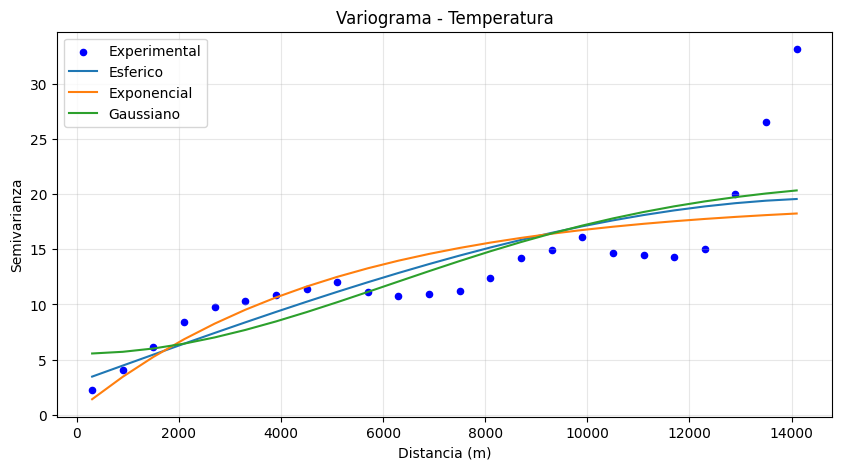

Parámetros del variograma:
  Modelo: esferico
  Nugget: 2.96
  Sill: 16.68
  Range: 15000 m

Ejecutando Kriging con modelo: spherical
Kriging completado. Matriz de predicción: (80, 80)


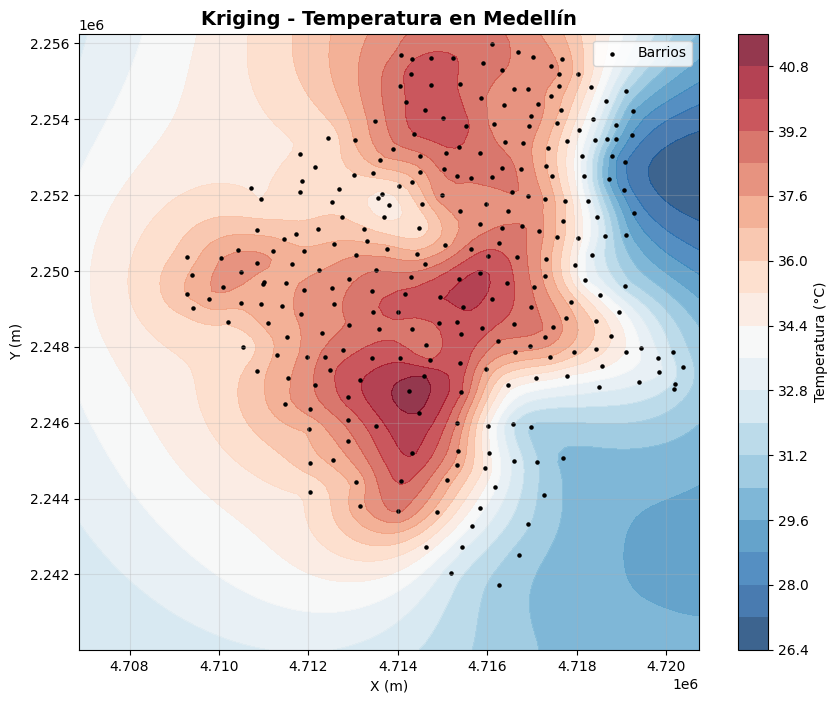

Mapa de predicción guardado en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados_Superficies/Kriging_Prediccion.png


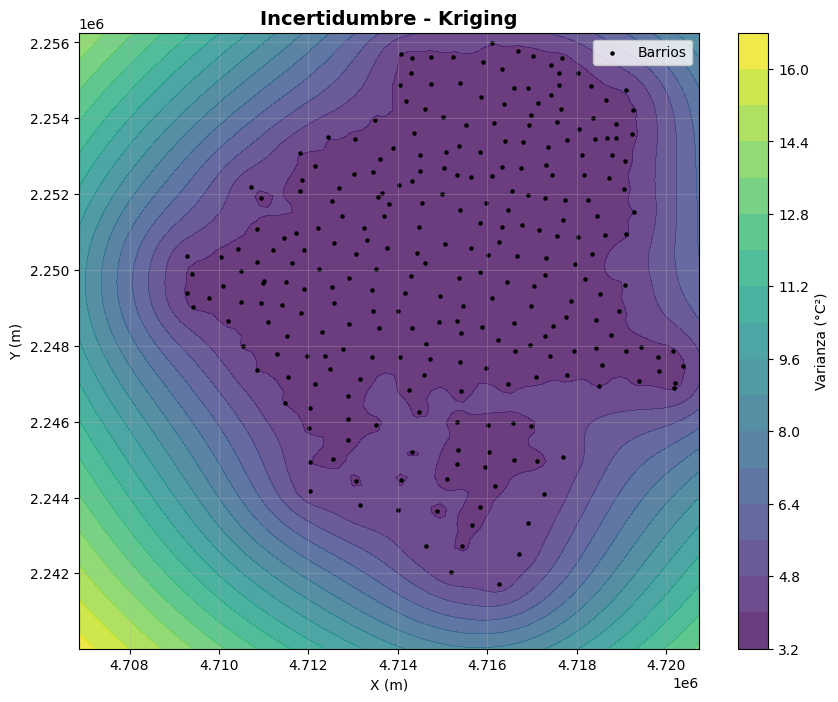

Mapa de incertidumbre guardado en: /content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados_Superficies/Kriging_Incertidumbre.png
RESULTADOS DEL KRIGING
Modelo: Esferico -> spherical
Nugget: 2.96
Sill: 16.68
Range: 15000 m

Temp. mínima predicha: 26.62 °C
Temp. máxima predicha: 41.23 °C
Temp. media predicha: 34.60 °C

Varianza media: 6.17 °C²


In [ ]:
# ============================================
# 0. INSTALAR DEPENDENCIAS
# ============================================
!pip install pykrige scikit-learn -q

# ============================================
# 1. IMPORTAR LIBRERÍAS
# ============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.optimize import curve_fit
from pykrige.ok import OrdinaryKriging
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. CARGAR TUS DATOS (SOLO ÁREA URBANA)
# ============================================
# RUTAS DE ENTRADA
ruta_zonas = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Zonas_Medellin.gpkg"
ruta_temp = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Temperatura_por_zona.csv"

# RUTA PARA GUARDAR RESULTADOS
ruta_resultados = "/content/drive/My Drive/Analisis_Geoespacial/Proyecto_Curso/Resultados_Superficies"
if not os.path.exists(ruta_resultados):
    os.makedirs(ruta_resultados)

# Cargar zonas y filtrar solo urbano
zonas = gpd.read_file(ruta_zonas)
zonas_urbano = zonas[zonas['Tipo'] == 'Urbano'].copy()

# Cargar temperatura y calcular promedio por barrio
df_temp = pd.read_csv(ruta_temp)
temp_promedio = df_temp.groupby('ID').agg({'Temp_media': 'mean'}).reset_index()

# Unir temperatura a los barrios
zonas_urbano = zonas_urbano.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_urbano = zonas_urbano.dropna(subset=['Temp_media'])

print(f"Barrios urbanos: {len(zonas_urbano)}")

# ============================================
# 3. EXTRAER COORDENADAS Y VALORES
# ============================================
zonas_urbano['centroid'] = zonas_urbano.geometry.centroid
coords = np.column_stack((zonas_urbano['centroid'].x, zonas_urbano['centroid'].y))
values = zonas_urbano['Temp_media'].values.astype(float)

# ============================================
# 4. VARIOGRAMA EXPERIMENTAL (MANUAL)
# ============================================
def variograma_experimental(coords, values, max_dist=15000, n_bins=25):
    dist = cdist(coords, coords)
    diff = (values[:, None] - values[None, :]) ** 2
    idx = np.triu_indices_from(dist, k=1)
    dist, diff = dist[idx], diff[idx]

    bins = np.linspace(0, max_dist, n_bins + 1)
    centers = (bins[:-1] + bins[1:]) / 2
    gamma, counts = [], []

    for i in range(n_bins):
        mask = (dist >= bins[i]) & (dist < bins[i+1])
        counts.append(mask.sum())
        gamma.append(np.mean(diff[mask]) / 2 if mask.any() else np.nan)

    gamma = np.array(gamma)
    valid = ~np.isnan(gamma)
    return centers[valid], gamma[valid]

dist_bins, gamma_exp = variograma_experimental(coords, values)
print(f"Variograma: {len(dist_bins)} bins")

# ============================================
# 5. MODELOS TEÓRICOS Y AJUSTE
# ============================================
def modelo_esferico(h, nugget, sill, r):
    h = np.array(h)
    gamma = np.zeros_like(h)
    mask = h < r
    gamma[mask] = nugget + sill * (1.5*h[mask]/r - 0.5*(h[mask]/r)**3)
    gamma[~mask] = nugget + sill
    return gamma

def modelo_exponencial(h, nugget, sill, r):
    return nugget + sill * (1 - np.exp(-3*h/r))

def modelo_gaussiano(h, nugget, sill, r):
    return nugget + sill * (1 - np.exp(-3*(h/r)**2))

# Ajuste de modelos
modelos = {'esferico': modelo_esferico, 'exponencial': modelo_exponencial, 'gaussiano': modelo_gaussiano}
params, preds = {}, {}

for nombre, func in modelos.items():
    try:
        p0 = [gamma_exp[0], gamma_exp[-1]-gamma_exp[0], dist_bins[np.argmin(np.abs(gamma_exp - gamma_exp[-1]*0.95))]]
        popt, _ = curve_fit(func, dist_bins, gamma_exp, p0=p0, bounds=([0,0,100], [np.inf,np.inf,15000]), maxfev=5000)
        params[nombre], preds[nombre] = popt, func(dist_bins, *popt)
        print(f"{nombre}: nugget={popt[0]:.2f}, sill={popt[1]:.2f}, range={popt[2]:.0f}")
    except:
        print(f"{nombre}: no convergió")

# Selección del mejor modelo (el primero que convergió)
mejor = list(params.keys())[0] if params else 'esferico'
nugget, sill, rango = params.get(mejor, [0.1, values.var()*0.8, 5000])

# ============================================
# 6. GRAFICAR VARIOGRAMA
# ============================================
plt.figure(figsize=(10,5))
plt.scatter(dist_bins, gamma_exp, color='blue', label='Experimental', s=20)
for nombre, pred in preds.items():
    plt.plot(dist_bins, pred, label=nombre.capitalize())
plt.xlabel('Distancia (m)')
plt.ylabel('Semivarianza')
plt.title('Variograma - Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(ruta_resultados, "Variograma.png"), dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# KRIGING ORDINARIO (SOLO LA PARTE FINAL)
# ============================================

# Asegúrate de tener los parámetros del variograma de la ejecución anterior
# Si no los tienes, usa estos valores por defecto (ajústalos si es necesario)
try:
    # Intenta usar los parámetros que ya calculaste
    nugget = nugget
    sill = sill
    rango = rango
    mejor = mejor
except:
    # Si no existen, usa valores por defecto
    nugget = 0.1
    sill = values.var() * 0.8
    rango = 5000
    mejor = 'esferico'
    print("Usando valores por defecto para los parámetros del variograma")

print(f"Parámetros del variograma:")
print(f"  Modelo: {mejor}")
print(f"  Nugget: {nugget:.2f}")
print(f"  Sill: {sill:.2f}")
print(f"  Range: {rango:.0f} m")

# ============================================
# CREAR CUADRÍCULA PARA LA PREDICCIÓN
# ============================================
xmin, ymin, xmax, ymax = zonas_urbano.total_bounds
gridx = np.linspace(xmin, xmax, 80)
gridy = np.linspace(ymin, ymax, 80)

# ============================================
# KRIGING CON PYKRIGE
# ============================================
# Mapeo de nombres de español a inglés
nombre_modelo_ingles = {
    'esferico': 'spherical',
    'exponencial': 'exponential',
    'gaussiano': 'gaussian'
}
modelo_ok = nombre_modelo_ingles.get(mejor, 'spherical')

print(f"\nEjecutando Kriging con modelo: {modelo_ok}")

ok = OrdinaryKriging(
    zonas_urbano['centroid'].x,
    zonas_urbano['centroid'].y,
    values,
    variogram_model=modelo_ok,
    variogram_parameters={'nugget': nugget, 'sill': sill, 'range': rango},
    verbose=False,
    enable_plotting=False
)

# Realizar la predicción
z_pred, z_var = ok.execute('grid', gridx, gridy)
print(f"Kriging completado. Matriz de predicción: {z_pred.shape}")

# ============================================
# MAPA DE PREDICCIÓN
# ============================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Mapa de predicción
im = ax.contourf(gridx, gridy, z_pred, levels=20, cmap='RdBu_r', alpha=0.8)

# Puntos originales
ax.scatter(
    zonas_urbano['centroid'].x,
    zonas_urbano['centroid'].y,
    c='black', s=5, label='Barrios'
)

# Configuración
plt.colorbar(im, ax=ax, label='Temperatura (°C)')
ax.set_title('Kriging - Temperatura en Medellín', fontsize=14, fontweight='bold')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)

# Guardar
plt.savefig(os.path.join(ruta_resultados, "Kriging_Prediccion.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Mapa de predicción guardado en: {os.path.join(ruta_resultados, 'Kriging_Prediccion.png')}")

# ============================================
# MAPA DE INCERTIDUMBRE
# ============================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Mapa de varianza
im = ax.contourf(gridx, gridy, z_var, levels=20, cmap='viridis', alpha=0.8)

# Puntos originales
ax.scatter(
    zonas_urbano['centroid'].x,
    zonas_urbano['centroid'].y,
    c='black', s=5, label='Barrios'
)

# Configuración
plt.colorbar(im, ax=ax, label='Varianza (°C²)')
ax.set_title('Incertidumbre - Kriging', fontsize=14, fontweight='bold')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
ax.grid(True, alpha=0.3)

# Guardar
plt.savefig(os.path.join(ruta_resultados, "Kriging_Incertidumbre.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"Mapa de incertidumbre guardado en: {os.path.join(ruta_resultados, 'Kriging_Incertidumbre.png')}")

# ============================================
# RESULTADOS NUMÉRICOS
# ============================================
print("RESULTADOS DEL KRIGING")
print(f"Modelo: {mejor.capitalize()} -> {modelo_ok}")
print(f"Nugget: {nugget:.2f}")
print(f"Sill: {sill:.2f}")
print(f"Range: {rango:.0f} m")
print(f"\nTemp. mínima predicha: {z_pred.min():.2f} °C")
print(f"Temp. máxima predicha: {z_pred.max():.2f} °C")
print(f"Temp. media predicha: {z_pred.mean():.2f} °C")
print(f"\nVarianza media: {z_var.mean():.2f} °C²")